# Tidy Data Project: 2008 Olympic Medalists

In this notebook, I clean and reshape the 2008 Olympic Medalists dataset using tidy data principles.

The goal is to transform the dataset so that:

Each variable is in its own column
Each observation is in its own row
Each type of observational unit is clearly organized

After cleaning the dataset, I perform exploratory data analysis using pivot tables and visualizations.

This follows concepts from the Pandas Cheat Sheet and Hadley Wickham’s Tidy Data principles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Load and Inspect the Data

First, I load the dataset and inspect its structure. This helps me understand the column names, data types, and general layout before cleaning.

In [2]:
df = pd.read_csv("Data/olympics_08_medalists.csv")

df.head()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   medalist_name                 1875 non-null   str  
 1   male_archery                  11 non-null     str  
 2   female_archery                9 non-null      str  
 3   male_athletics                85 non-null     str  
 4   female_athletics              81 non-null     str  
 5   male_badminton                12 non-null     str  
 6   female_badminton              10 non-null     str  
 7   male_baseball                 72 non-null     str  
 8   male_basketball               35 non-null     str  
 9   female_basketball             36 non-null     str  
 10  male_boxing                   44 non-null     str  
 11  male_canoeing and kayaking    53 non-null     str  
 12  female_canoeing and kayaking  21 non-null     str  
 13  male_road bicycle racing      5 non-null    

## Step 2: Identify Why the Data is Untidy

This dataset is untidy because the column names appear to combine multiple pieces of information into a single variable. Instead of having separate columns for each variable, some information is stored in the column headers themselves.

To make the data tidy, I need to reshape it so that the column names become values in a single column. This will allow each variable to be separated more clearly.

## Step 3: Reshape the Data Using Melt

I use pd.melt() to convert the dataset from wide format to long format.

This transformation creates:

One column containing the original column names
One column containing the medal values
One row per observation

I also rename medalist_name to Name and remove any rows with missing medal values.

In [4]:
# Melt the data (wide → long)
tidy_df = df.melt(
    id_vars=["medalist_name"],
    var_name="Medal_Type",
    value_name="Medal"
)

tidy_df = tidy_df.rename(columns={"medalist_name": "Name"})

# Drop empty rows
tidy_df = tidy_df.dropna(subset=["Medal"].copy())

tidy_df.head()

,Name,Medal_Type,Medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold


## Step 4: Split & Clean the Combined Column

Splitting Data: Breaks apart the messy Medal_Type column (e.g., "Men_100m") into two separate Gender and Sport columns.

Formatting Text: Cleans up spacing, removes leftover underscores, and capitalizes all words so the data is uniform.

Prepping for Analysis: Deletes the old Medal_Type column to reduce clutter and adds a Count column (set to 1) so you can easily tally up totals later.



In [5]:

tidy_df[["Gender", "Sport"]] = tidy_df["Medal_Type"].str.split("_", n=1, expand=True)

tidy_df["Sport"] = tidy_df["Sport"].str.replace("_", " ", regex=False).str.strip().str.title()
tidy_df["Gender"] = tidy_df["Gender"].str.strip().str.title()
tidy_df["Medal"] = tidy_df["Medal"].str.strip().str.title()

tidy_df = tidy_df.drop(columns=["Medal_Type"], errors="ignore")

tidy_df["Count"] = 1

tidy_df.head()


,Name,Medal,Gender,Sport,Count
177,Bair Badënov,Bronze,Male,Archery,1
676,Ilario Di Buò,Silver,Male,Archery,1
682,Im Dong-hyun,Gold,Male,Archery,1
760,Jiang Lin,Bronze,Male,Archery,1
920,Lee Chang-hwan,Gold,Male,Archery,1


## Step 5: Final Tidy Dataset

At this point, the dataset follows tidy data principles more closely:

- each variable has its own column
- each row represents a single observation
- the data is now structured for analysis

The final tidy dataset includes the athlete’s name, medal value, gender, sport, and a count column.

In [6]:
tidy_df.head(100)

,Name,Medal,Gender,Sport,Count
177,Bair Badënov,Bronze,Male,Archery,1
676,Ilario Di Buò,Silver,Male,Archery,1
682,Im Dong-hyun,Gold,Male,Archery,1
760,Jiang Lin,Bronze,Male,Archery,1
920,Lee Chang-hwan,Gold,Male,Archery,1
...,...,...,...,...,...
5429,Tsegaye Kebede,Bronze,Male,Athletics,1
5435,Usain Bolt,Gold,Male,Athletics,1
5436,Vadim Devyatovskiy,Silver,Male,Athletics,1
5441,Valeriy Borchin,Gold,Male,Athletics,1


## Step 7: Pivot Table / Aggregation

Now that the data is tidy, I can summarize it using a pivot table.

Here, I compare the number of medal records across sports and gender categories. The Count column allows me to total the number of observations in each group.

In [7]:
pivot_table = tidy_df.pivot_table(
    index="Sport",
    columns="Gender",
    values="Count",
    aggfunc="sum",
    fill_value=0
)

pivot_table

Gender,Female,Male
Sport,,
Archery,9,11
Artistic Gymnastics,20,29
Association Football,54,55
Athletics,81,85
Badminton,10,12
Baseball,0,72
Basketball,36,35
Beach Volleyball,6,6
Bmx,3,3


## Step 8: Visualization 1 – Sports by Gender

Using the pivot table, I create a bar chart to compare medal counts across sports, broken down by gender.

This helps show which sports have more medal records and how those records are distributed by gender.

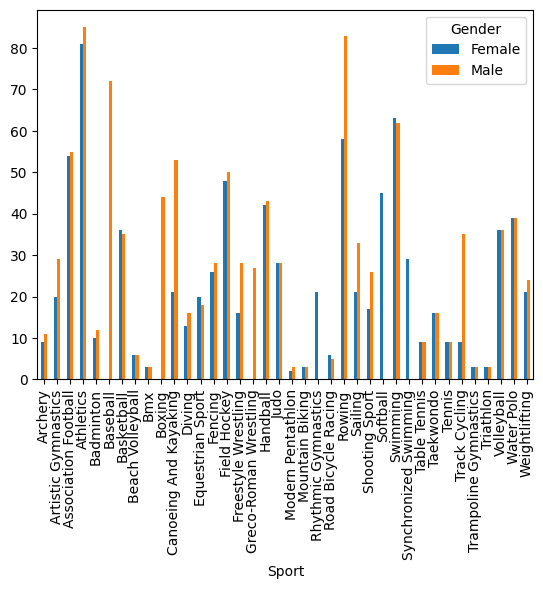

In [8]:
pivot_table.plot(kind="bar")
plt.show()

## Step 9: Visualization 2 – Total Medals by Type

Next, I group the data by medal type and count how many times each medal appears.

This visualization shows the overall distribution of medal types in the cleaned dataset.

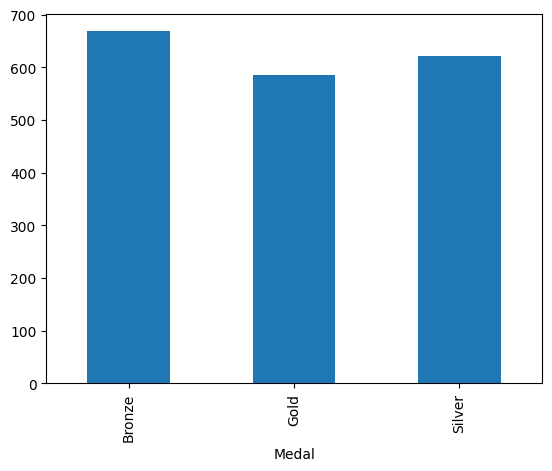

In [9]:
medal_totals = tidy_df.groupby("Medal")["Count"].sum()

medal_totals.plot(kind="bar")

plt.show()